# asses the history of runs


In [39]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt



/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


In [60]:
df=pd.read_csv("/fred/oz061/kandrych/smac/test_new_features/after_optimisation/trials.csv")
results_dir="/fred/oz061/kandrych/smac/test_new_features/after_optimisation/"
df

,alpha_viscosity,distance_pc,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gamma_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.020699,1220.0,47.011930,0.001,1.401312,-1.233564,100.0,1.063392,0.498057,0.397948,0.8,1.166834,8,1850920004,2.0,228.655047,243.696087,1
1,0.003739,1220.0,33.168058,0.001,1.126624,0.638861,50.0,1.540537,0.886917,0.102527,0.8,0.898612,10,1850920004,2.0,399.366143,226.657204,1
2,0.016318,1220.0,42.159667,0.002,1.534936,0.682955,50.0,1.538179,0.711474,0.245565,0.7,-0.530747,6,1850920004,2.0,498.508237,291.269012,1
3,0.024856,1220.0,13.628440,0.001,1.035854,1.301495,100.0,1.741443,0.779095,0.140095,0.8,1.366487,7,1850920004,2.0,1251.904766,292.457130,1
4,0.049401,1220.0,19.169474,0.001,1.165292,-0.870436,200.0,0.984467,0.156124,0.466504,0.7,0.532293,9,1850920004,2.0,1418.135221,269.203455,1
5,0.049401,1220.0,15.302166,0.001,1.200340,-0.870436,50.0,0.984467,0.156124,0.437815,0.7,0.532293,5,1850920004,2.0,2111.069867,353.701867,1
6,0.001386,1220.0,17.563919,0.001,1.105279,1.327689,50.0,1.303313,0.170684,0.464319,0.7,0.753188,4,1850920004,2.0,2480.339145,346.510484,1
7,0.000529,1220.0,37.476528,0.002,1.101356,-1.887291,100.0,1.035736,0.532745,0.783742,0.7,-0.225440,1,1850920004,2.0,2871.105400,384.995210,1
8,0.000590,1220.0,28.526374,0.001,1.192473,-0.120642,50.0,0.964701,0.382477,0.589113,0.8,-0.179347,3,1850920004,2.0,2922.184202,341.109890,1
9,0.000348,1220.0,12.093784,0.001,1.053690,1.863932,50.0,1.650519,0.375901,0.688989,0.8,0.417907,2,1850920004,2.0,5050.748165,410.243929,1


### Best configs table (at max budget)

In [11]:
top = df[df["budget"] == df["budget"].max()].nsmallest(5, "cost")
print("Top 5 max budget trials:")
top
#top.to_csv(results_dir / "top5_maxbudget.csv", index=False)



Top 5 max budget trials:


,alpha_viscosity,distance_pc,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gamma_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.020699,1220.0,47.011930,0.001,1.401312,-1.233564,100.0,1.063392,0.498057,0.397948,0.8,1.166834,8,1850920004,2.0,228.655047,243.696087,1
1,0.003739,1220.0,33.168058,0.001,1.126624,0.638861,50.0,1.540537,0.886917,0.102527,0.8,0.898612,10,1850920004,2.0,399.366143,226.657204,1
2,0.016318,1220.0,42.159667,0.002,1.534936,0.682955,50.0,1.538179,0.711474,0.245565,0.7,-0.530747,6,1850920004,2.0,498.508237,291.269012,1
3,0.024856,1220.0,13.628440,0.001,1.035854,1.301495,100.0,1.741443,0.779095,0.140095,0.8,1.366487,7,1850920004,2.0,1251.904766,292.457130,1
4,0.049401,1220.0,19.169474,0.001,1.165292,-0.870436,200.0,0.984467,0.156124,0.466504,0.7,0.532293,9,1850920004,2.0,1418.135221,269.203455,1


### Pairwise sanity checks (parameter vs cost)


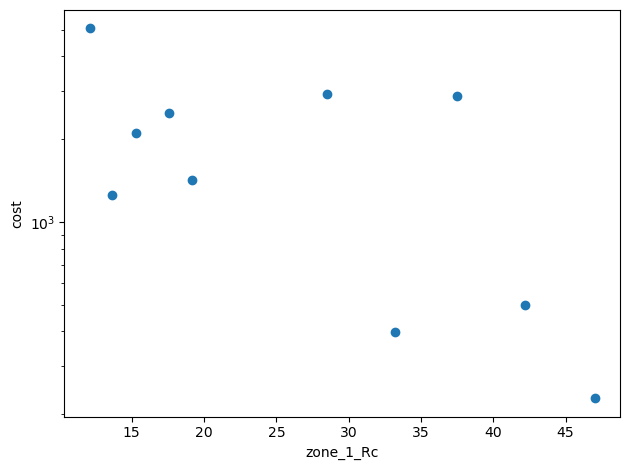

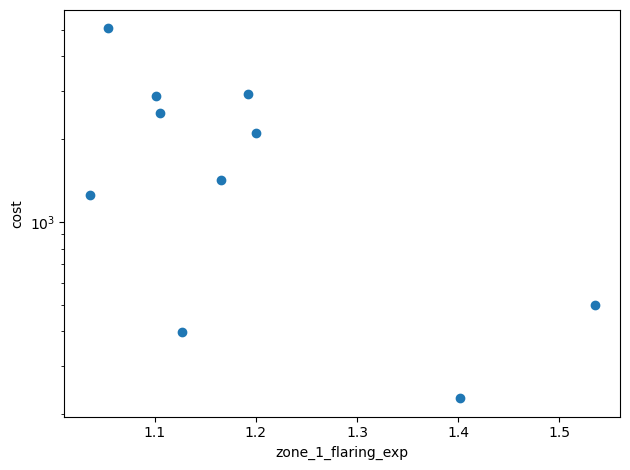

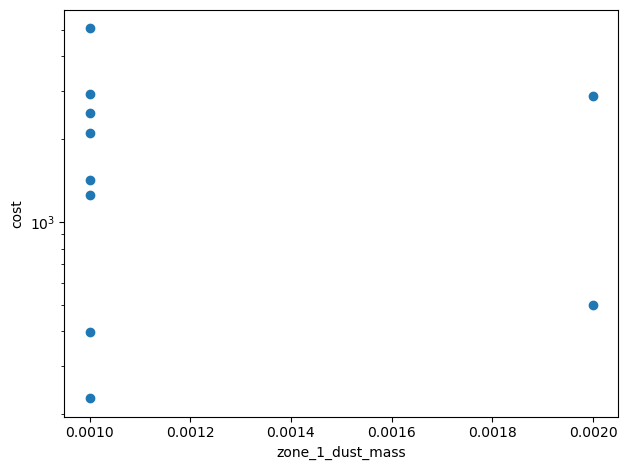

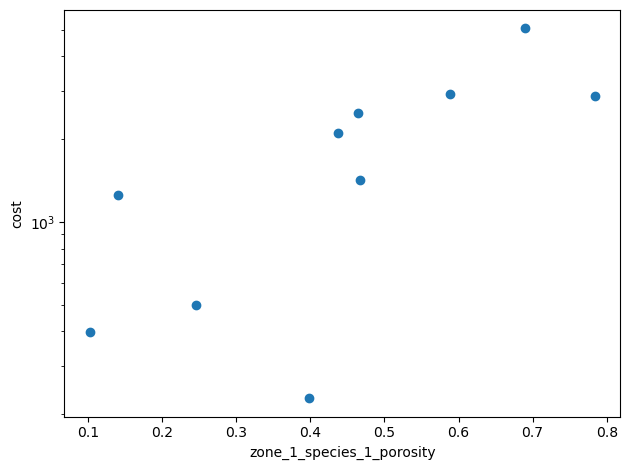

In [23]:


for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:  # rename to your actual names
    if p in df.columns:
        plt.figure()
        plt.scatter(df[p], df["cost"])
        plt.xlabel(p); plt.ylabel("cost")
        plt.yscale("log")  # often helpful
        plt.tight_layout()
        plt.show()
        #plt.savefig(results_dir / f"scatter_{p}.png", dpi=150)
        #plt.close()


### Slice by budget (does the story change with fidelity?)

In [24]:
df.groupby("budget")["cost"].describe()#.to_csv(results_dir / "cost_by_budget.csv")


,count,mean,std,min,25%,50%,75%,max
budget,,,,,,,,
2.0,10.0,1923.201619,1488.951058,228.655047,686.857369,1764.602544,2773.413836,5050.748165


### Parameter importance (fast, practical)

In [32]:
def binned_medians(df, param, bins=2):
    s = df[[param, "cost"]].dropna()
    s["bin"] = pd.qcut(s[param], q=bins, duplicates="drop")
    return s.groupby("bin", observed=True)["cost"].median().sort_values()

for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:
    if p in df.columns:
        bm = binned_medians(df[df["budget"] == df["budget"].max()], p)
        print(f"Binned medians for {p}:")
        print(bm)
        #bm.to_csv(results_dir / f"binned_median_{p}.csv")


Binned medians for zone_1_Rc:
bin
(23.848, 47.012]     498.508237
(12.093, 23.848]    2111.069867
Name: cost, dtype: float64
Binned medians for zone_1_flaring_exp:
bin
(1.146, 1.535]                 1418.135221
(1.0350000000000001, 1.146]    2480.339145
Name: cost, dtype: float64
Binned medians for zone_1_dust_mass:
bin
(0.0, 0.002]    1764.602544
Name: cost, dtype: float64
Binned medians for zone_1_species_1_porosity:
bin
(0.102, 0.451]     498.508237
(0.451, 0.784]    2871.105400
Name: cost, dtype: float64


### Clustering of “good” solutions (degeneracies)

In [ ]:
good = df[df["budget"] == df["budget"].max()].nsmallest(5, "cost")
good.describe()#.to_csv(results_dir / "good5_summary.csv")

,alpha_viscosity,distance_pc,zone_1_Rc,zone_1_dust_mass,zone_1_flaring_exp,zone_1_gamma_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
count,5.000000,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000e+00,5.0,5.000000,5.000000,5.0
mean,0.023002,1220.0,31.027514,0.001200,1.252804,0.103862,100.000000,1.373604,0.606333,0.270528,0.760000,0.686696,8.000000,1.850920e+09,2.0,759.313883,264.656578,1.0
std,0.016743,0.0,14.381839,0.000447,0.207545,1.094744,61.237244,0.330876,0.288981,0.158511,0.054772,0.748927,1.581139,0.000000e+00,0.0,537.557461,29.090639,0.0
min,0.003739,1220.0,13.628440,0.001000,1.035854,-1.233564,50.000000,0.984467,0.156124,0.102527,0.700000,-0.530747,6.000000,1.850920e+09,2.0,228.655047,226.657204,1.0
25%,0.016318,1220.0,19.169474,0.001000,1.126624,-0.870436,50.000000,1.063392,0.498057,0.140095,0.700000,0.532293,7.000000,1.850920e+09,2.0,399.366143,243.696087,1.0
50%,0.020699,1220.0,33.168058,0.001000,1.165292,0.638861,100.000000,1.538179,0.711474,0.245565,0.800000,0.898612,8.000000,1.850920e+09,2.0,498.508237,269.203455,1.0
75%,0.024856,1220.0,42.159667,0.001000,1.401312,0.682955,100.000000,1.540537,0.779095,0.397948,0.800000,1.166834,9.000000,1.850920e+09,2.0,1251.904766,291.269012,1.0
max,0.049401,1220.0,47.011930,0.002000,1.534936,1.301495,200.000000,1.741443,0.886917,0.466504,0.800000,1.366487,10.000000,1.850920e+09,2.0,1418.135221,292.457130,1.0


### Plot

In [35]:
curve = df.groupby(["config_id", "budget"])["cost"].min().reset_index()
curve#.to_csv(results_dir / "learning_curves.csv", index=False)


,config_id,budget,cost
0,1,2.0,2871.105400
1,2,2.0,5050.748165
2,3,2.0,2922.184202
3,4,2.0,2480.339145
4,5,2.0,2111.069867
5,6,2.0,498.508237
6,7,2.0,1251.904766
7,8,2.0,228.655047
8,9,2.0,1418.135221
9,10,2.0,399.366143


## For the cornerplot


SMAC does not give a true posterior.
Your corner plot represents a high-likelihood region sampled by Bayesian optimisation, not an MCMC posterior.

This is perfectly acceptable if you phrase it as:

“distribution of high-performing models”

In [56]:
# Restrict to highest fidelity
df_max = df[df["budget"] == df["budget"].max()].copy()

# Drop failed / NaN
df_max = df_max.dropna(subset=["cost"])

# Optional: keep only the best 30% of trials
q = 0.9
cost_cut = df_max["cost"].quantile(q)
df_sel = df_max[df_max["cost"] <= cost_cut]


In [63]:
exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc', "alpha_viscosity", 'zone_1_gas_to_dust', 'zone_1_species_1_amin'}

param_cols = [c for c in df_sel.columns if c not in exclude]
param_cols


['zone_1_Rc',
 'zone_1_dust_mass',
 'zone_1_flaring_exp',
 'zone_1_gamma_exp',
 'zone_1_scale_height',
 'zone_1_species_1_porosity',
 'zone_1_species_1_volume_fraction',
 'zone_1_surface_density_exp']

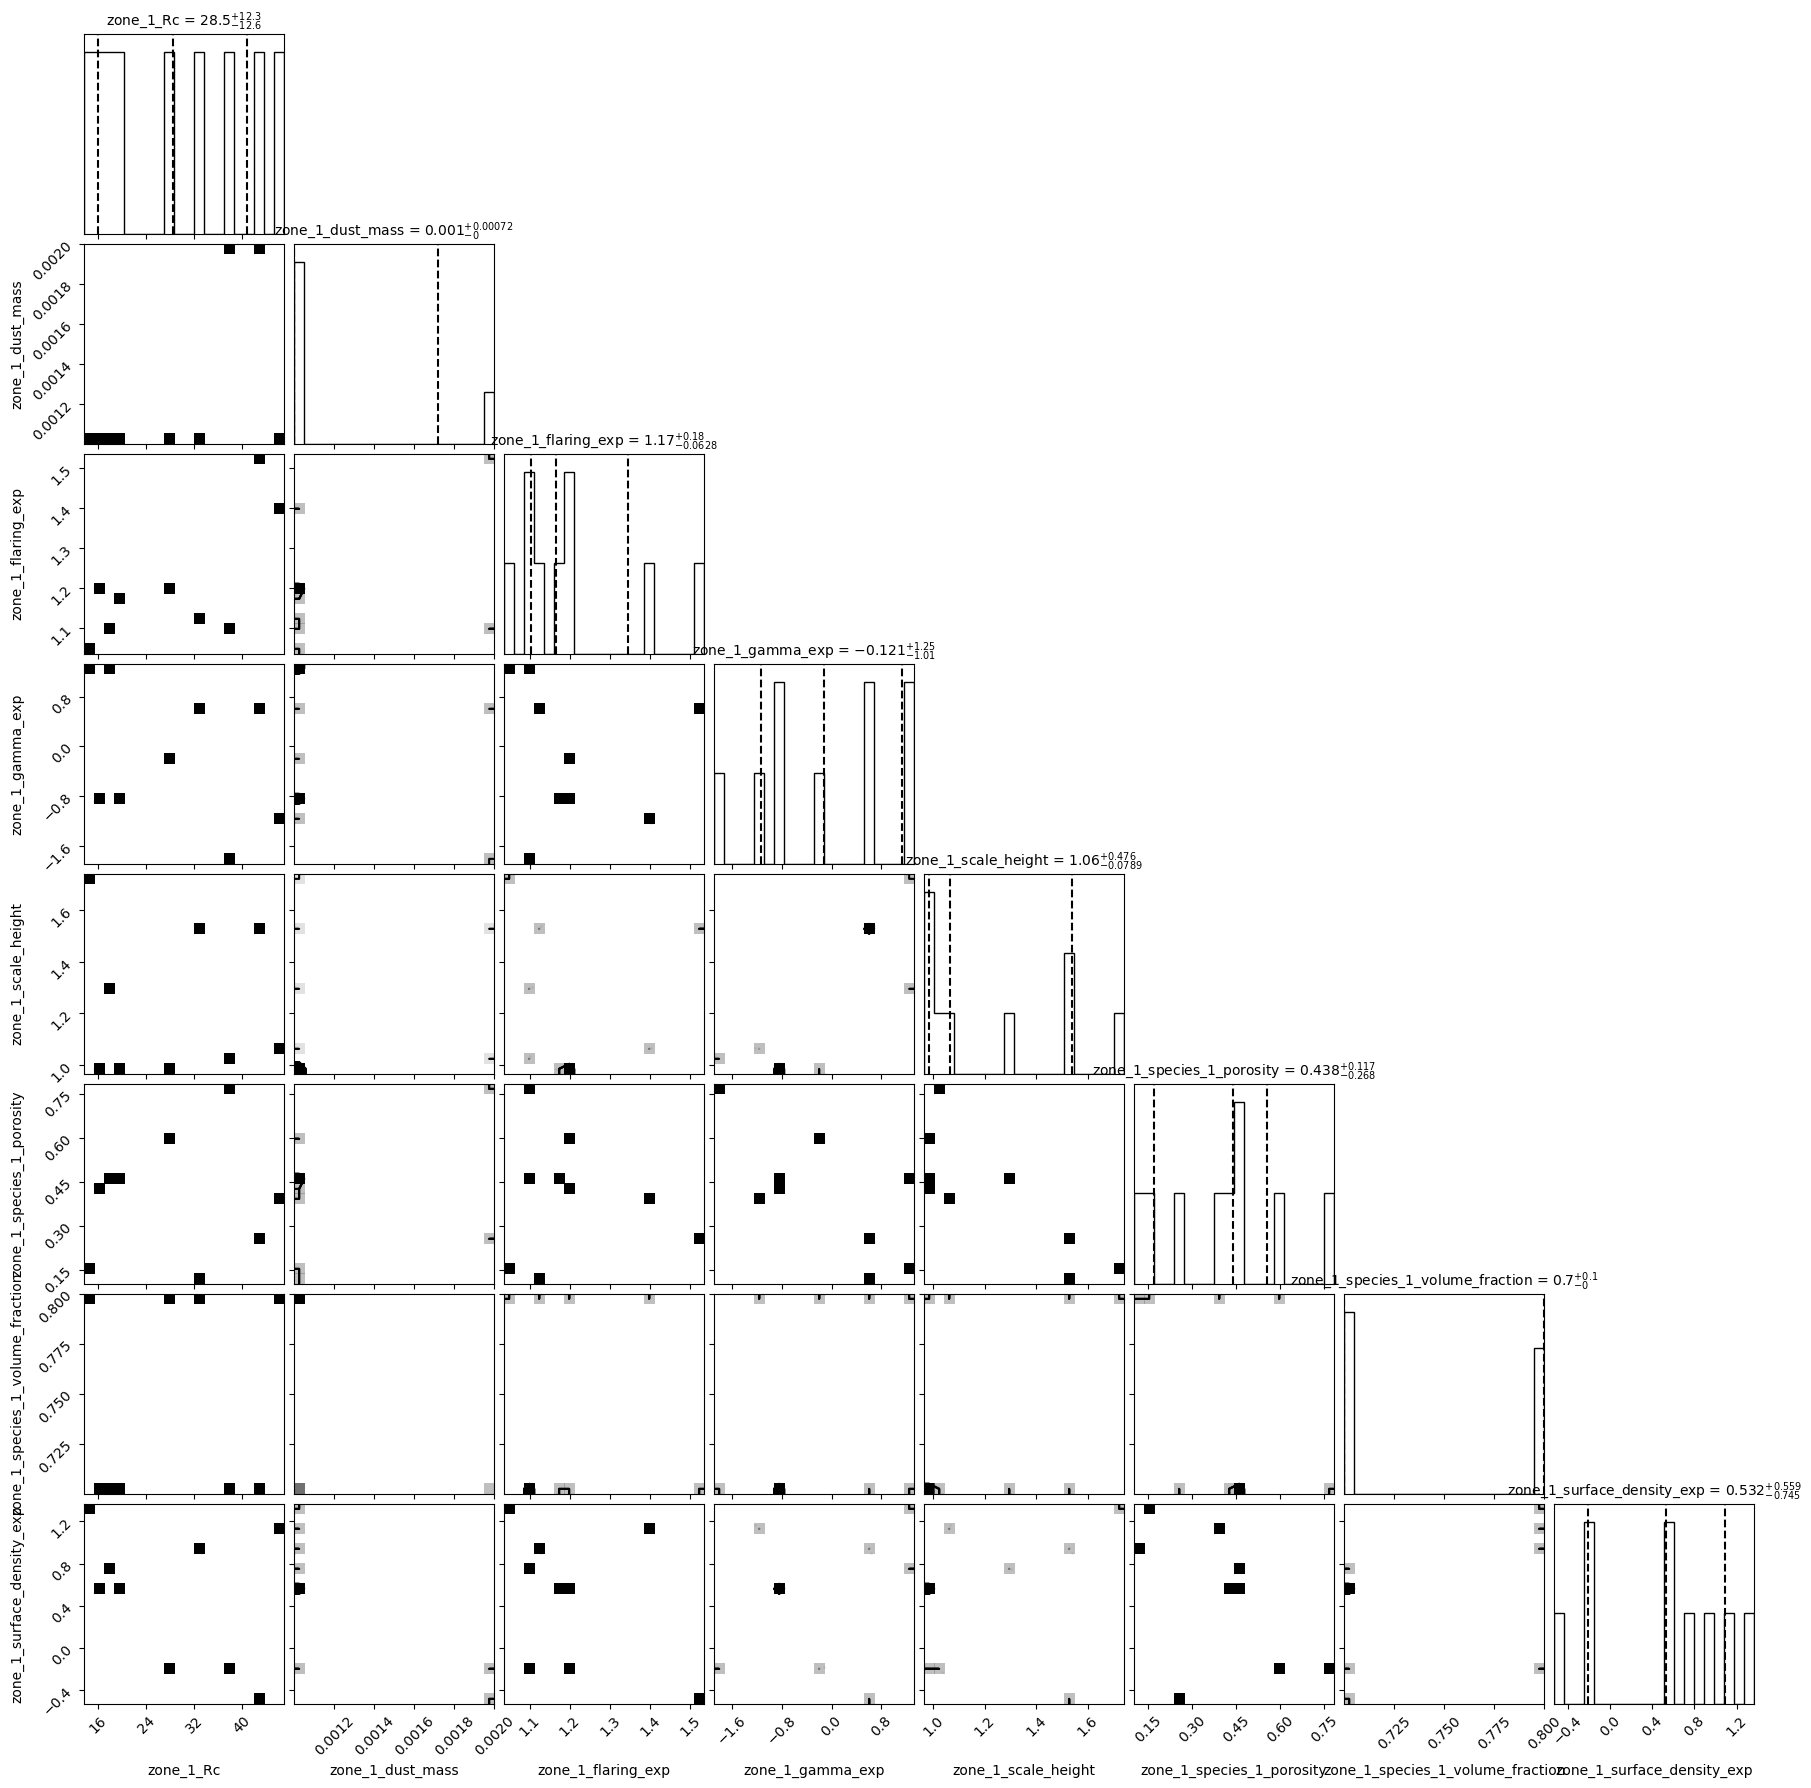

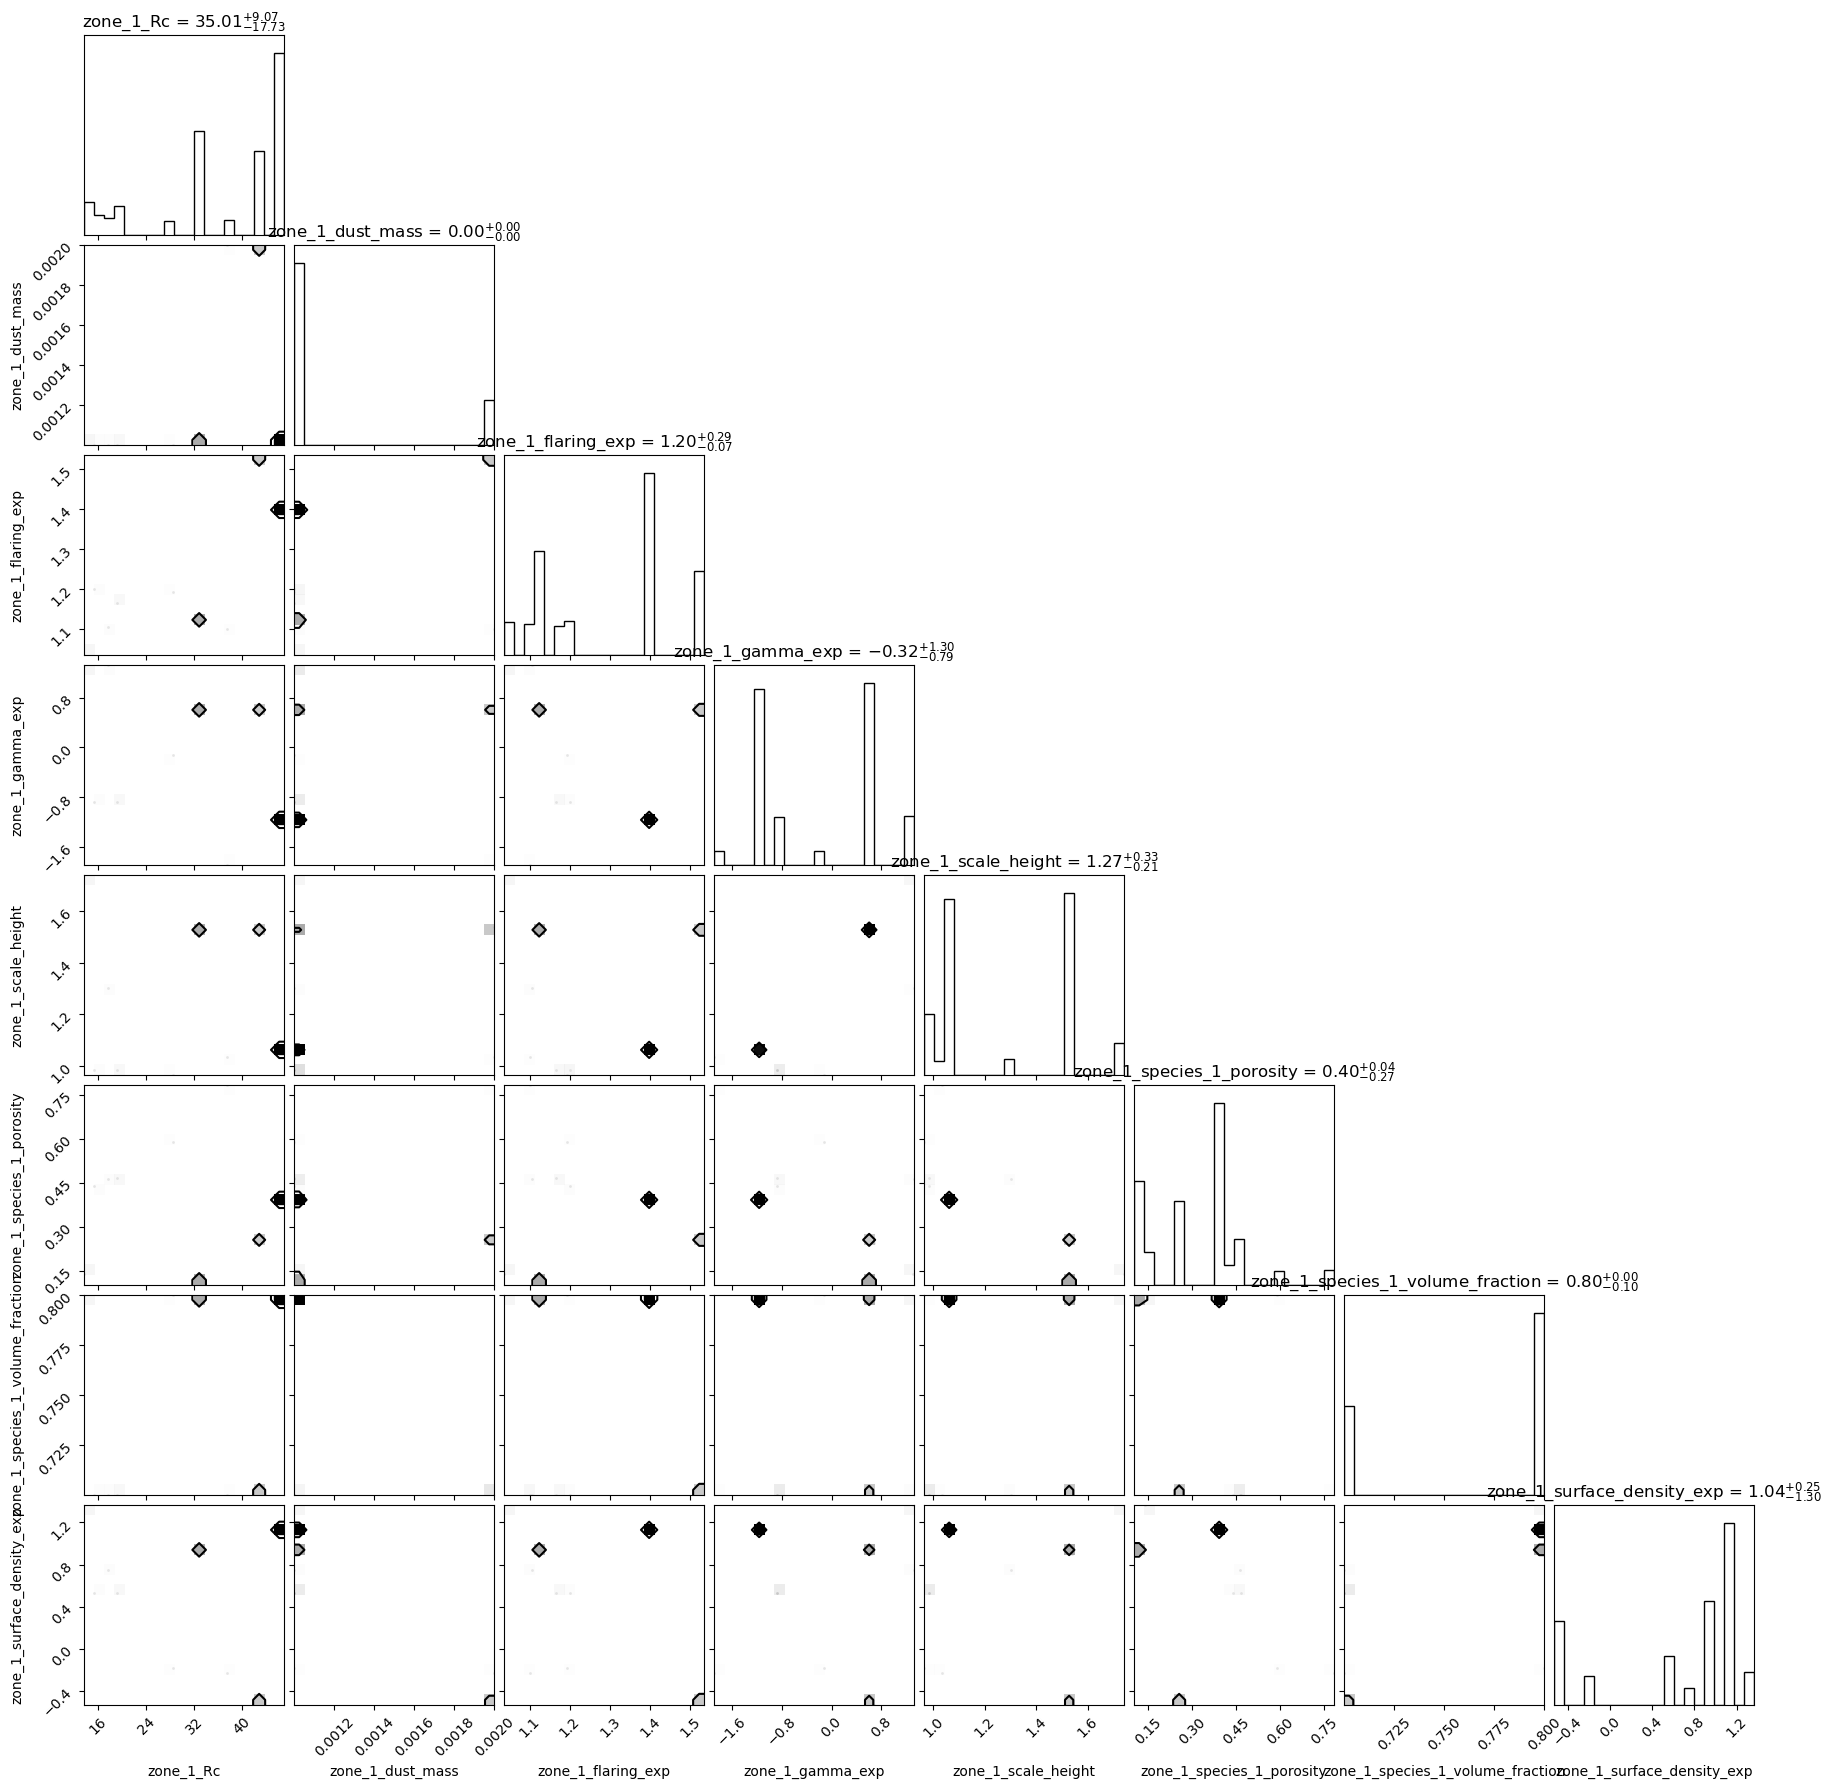

In [64]:
data = df_sel[param_cols].values

fig = corner.corner(
    data,
    labels=param_cols,
    truths=None,              # optional: known reference values
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
)

#fig.savefig(results_dir / "corner_all_params.png", dpi=150, bbox_inches="tight")
#plt.close(fig)

weights = 1.0 / df_sel["cost"].values

fig = corner.corner(
    data,
    labels=param_cols,
    weights=weights,
    show_titles=True,
)



In [ ]:
#just one function to do it
#WORKS

def make_corner_plot(
    df,
    params,
    *,
    budget=None,
    best_quantile=0.3,
    outfile="corner.png",
):

    d = df.copy()
    if budget is not None:
        d = d[d["budget"] == budget]

    d = d.dropna(subset=["cost"])
    cost_cut = d["cost"].quantile(best_quantile)
    d = d[d["cost"] <= cost_cut]

    data = d[params].values

    fig = corner.corner(
        data,
        labels=params,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".3g",
    )

    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.close(fig)




In [65]:
make_corner_plot(
    df,
    params=param_cols,
    budget=df["budget"].max(),
    outfile=results_dir+ "corner_best.png",
    best_quantile=0.9
)
